# 03a. EDA - Temporal Trends


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pathlib

PROCESSED_DATA_PATH = pathlib.Path("data/processed")
data_file = list(PROCESSED_DATA_PATH.glob("*_processed.parquet"))[0]
df = pd.read_parquet(data_file)
print(f"Loaded {len(df):,} records.")

Loaded 1,207,546 records.


## 1. Volume Trends
Visualize daily call volume over the 10-year period.

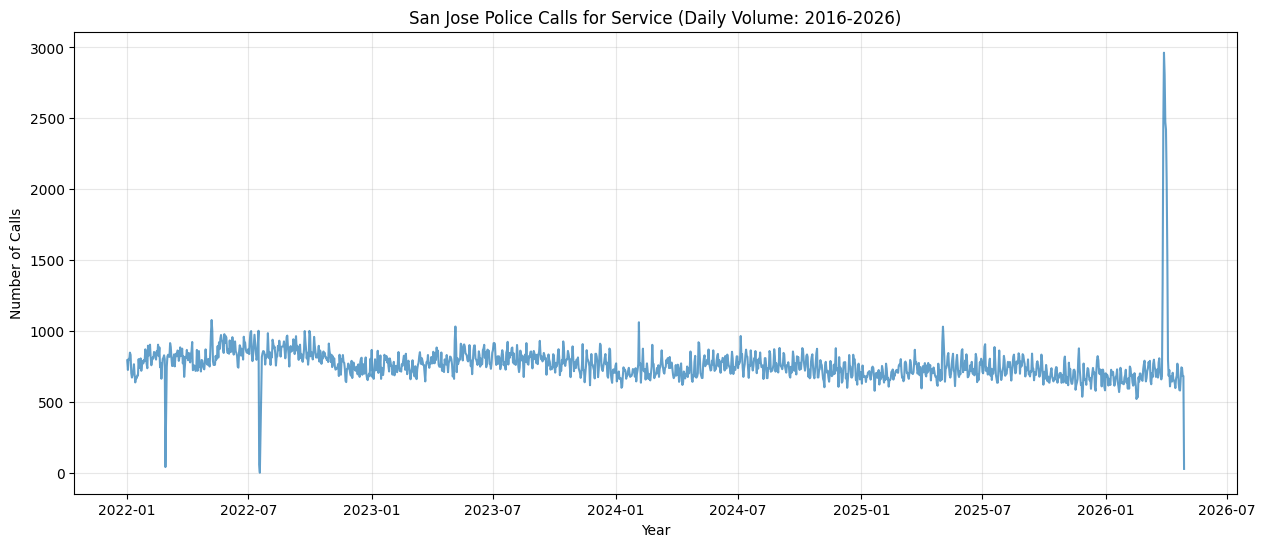

In [2]:
# Aggregate by day
df['year'] = df['CDTS'].dt.year
daily_calls = df.groupby(df['CDTS'].dt.date).size().reset_index(name='total_calls')
daily_calls['CDTS'] = pd.to_datetime(daily_calls['CDTS'])

plt.figure(figsize=(15, 6))
plt.plot(daily_calls['CDTS'], daily_calls['total_calls'], color='tab:blue', alpha=0.7)
plt.title("San Jose Police Calls for Service (Daily Volume: 2016-2026)")
plt.xlabel("Year")
plt.ylabel("Number of Calls")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Temporal Gaps
Identify and document missing data periods in the dataset.

In [3]:
all_days = pd.date_range(start=daily_calls['CDTS'].min(), end=daily_calls['CDTS'].max())
missing_days = all_days[~all_days.isin(daily_calls['CDTS'])]
print(f"Days with recorded data: {len(daily_calls)}")
print(f"Reporting gaps: {len(missing_days)}")
if len(missing_days) > 0:
    print("\nExamples of reporting gaps:")
    print(missing_days[:10])

Days with recorded data: 1576
Reporting gaps: 3

Examples of reporting gaps:
DatetimeIndex(['2022-02-28', '2022-07-19', '2022-07-20'], dtype='datetime64[s]', freq=None)


## 3. Monthly Seasonality
Analyze recurring annual cycles and monthly averages.

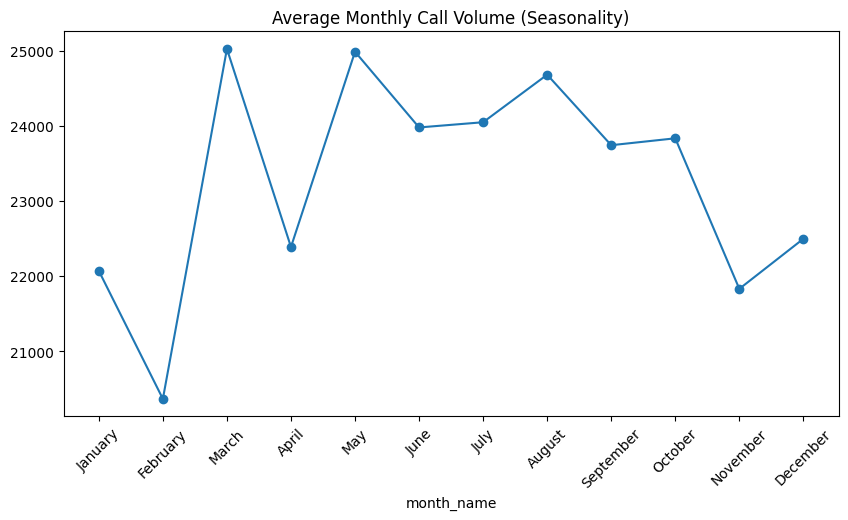

In [4]:
df['month_name'] = df['CDTS'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
seasonality = df.groupby(['year', 'month_name']).size().reset_index(name='count')
seasonality_avg = seasonality[seasonality['count'] > 0].groupby('month_name')['count'].mean().reindex(month_order)

plt.figure(figsize=(10, 5))
seasonality_avg.plot(kind='line', marker='o', color='tab:blue')
plt.title("Average Monthly Call Volume (Seasonality)")
plt.xticks(range(12), month_order, rotation=45)
plt.show()

## 4. Density Heatmaps
Map call volume by day of week and hour of day.

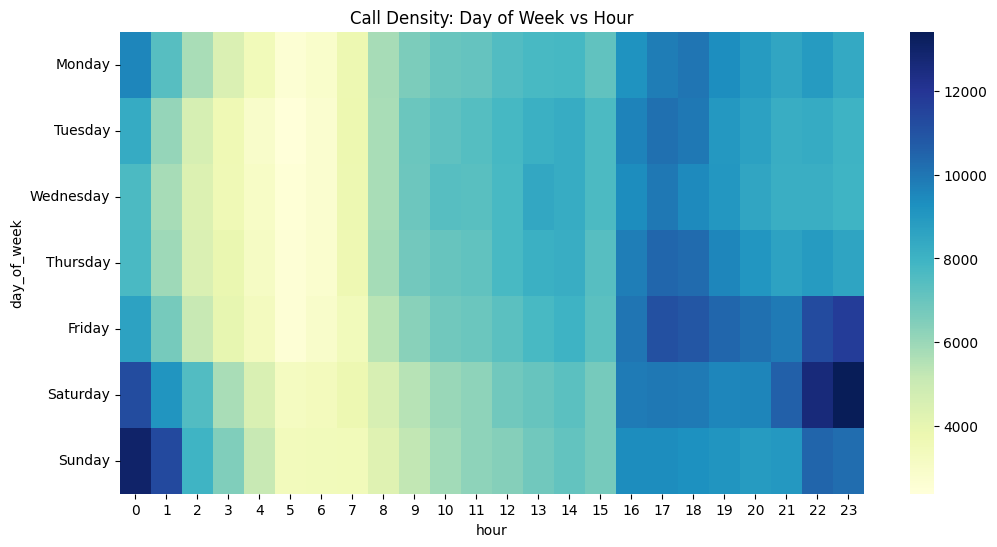

In [5]:
df['hour'] = df['CDTS'].dt.hour
df['day_of_week'] = df['CDTS'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack().reindex(day_order)

import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Call Density: Day of Week vs Hour")
plt.show()

## 5. Holiday Impact
Compare call volume on major holidays against the baseline average.

In [6]:
holidays = {'New Year': '-01-01', 'July 4th': '-07-04', 'Halloween': '-10-31'}
holiday_dates = []
for year in df['year'].unique():
    for date_str in holidays.values():
        holiday_dates.append(pd.to_datetime(f"{year}{date_str}").date())
avg_daily = daily_calls['total_calls'].mean()
holiday_avg = daily_calls[daily_calls['CDTS'].dt.date.isin(holiday_dates)]['total_calls'].mean()
print(f"Overall Average: {avg_daily:.2f}")
print(f"Holiday Average: {holiday_avg:.2f}")

Overall Average: 766.21
Holiday Average: 810.85


## 6. Peak Load Statistics
Identify the highest volume days and hours in history.

In [7]:
display(daily_calls.sort_values('total_calls', ascending=False).head(5))

,CDTS,total_calls
1545,2026-03-29,2963
1546,2026-03-30,2809
1547,2026-03-31,2474
1544,2026-03-28,2443
1548,2026-04-01,2422
